In [1]:
%matplotlib inline
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
import uproot
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
from scipy.optimize import curve_fit
from LHCb_ch_p import funcgeneral, models, analisis, mK, mPi

# Rutas de las carpetas
BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / 'Data'
Path('GChanels').mkdir(exist_ok = True)

print("Configuración cargada correctamente.")
print(f"Directorio de datos; {DATA_DIR}")

Configuración cargada correctamente.
Directorio de datos; /home/karna/Documentos/LHCb/Hackaton_2024/opendata-project-1.2/Data


# Canal $B^{\pm} \to K^{+}K^{-}K^{+}$


  CANAL: B⇾KKK

[1] Cargando datos...
  B2HHH_MagnetUp.root: 9,717 eventos
  B2HHH_MagnetDown.root: 14,178 eventos
  Total tras preselección: 23,895 eventos


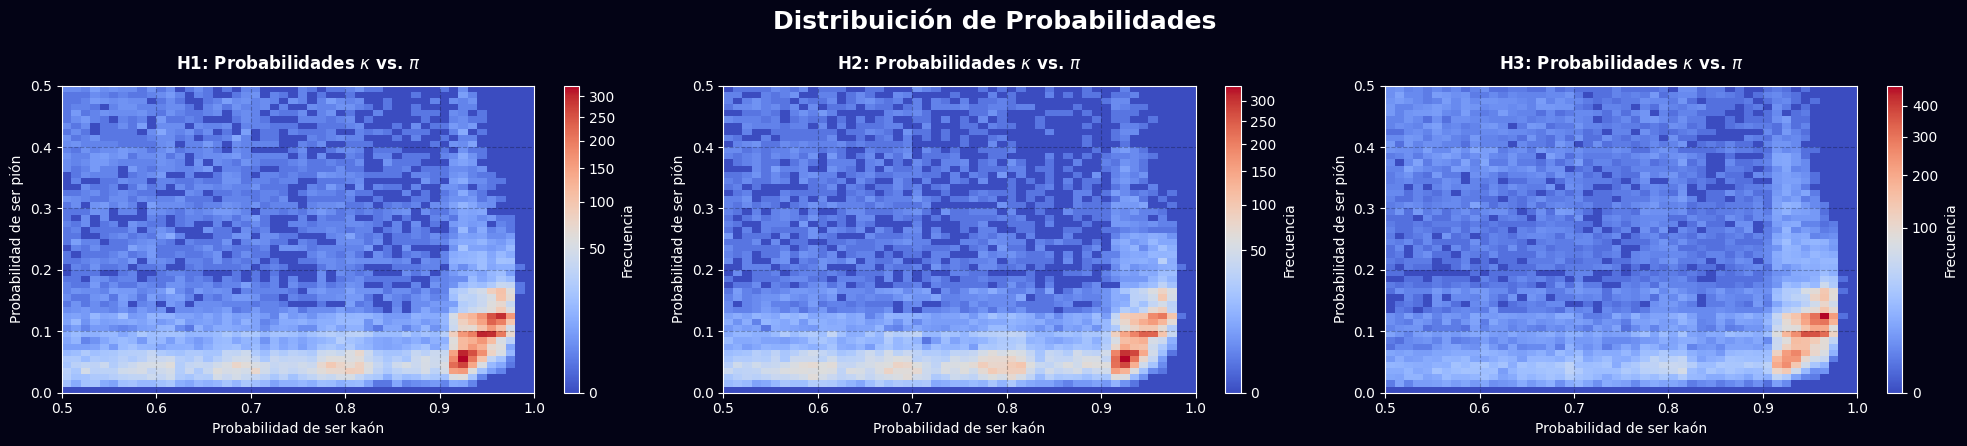


[2] Reconstruyendo masa invariante del B...

[3] Ajuste de la distribución de masa...
  B⁺: 12,390 candidatos en [5100.0,5500.0] [MeV/c²]
N_señal = 7940 ± 93
χ²/ndf  = 166.5 / 75
Media   = 5284.41 [MeV/c²]
  σ     = 17.82 [MeV/c²]
  B⁻: 11,505 candidatos en [5100.0,5500.0] [MeV/c²]
N_señal = 7256 ± 89
χ²/ndf  = 188.0 / 75
Media   = 5284.59 [MeV/c²]
  σ     = 17.87 [MeV/c²]


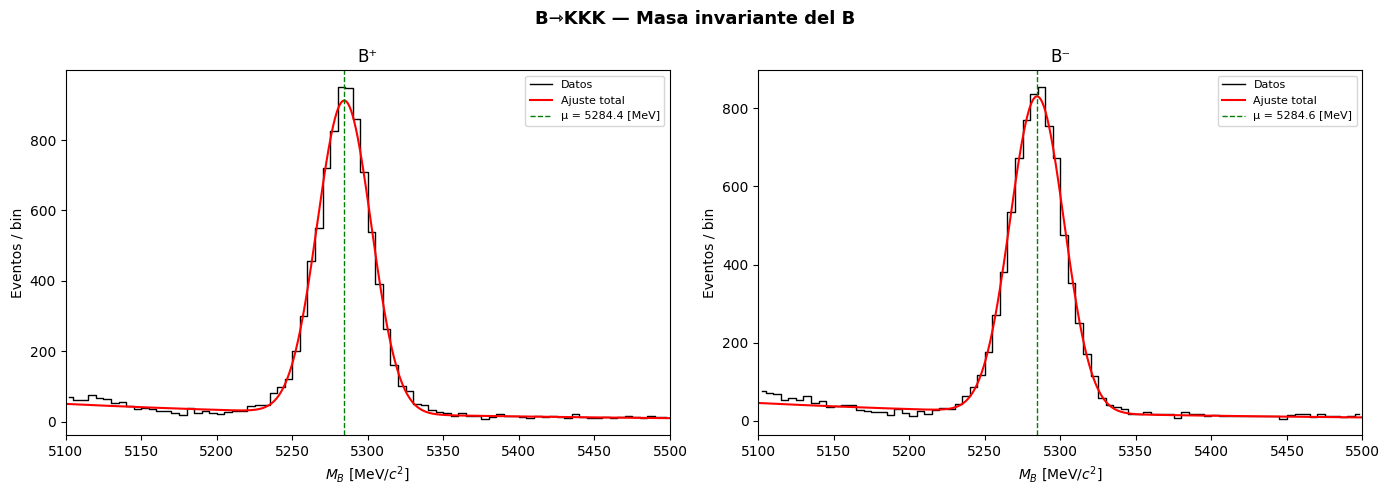


[5] Asimetría CP global (conteo simple)...

=== B⇾KKK — conteo simple ===
  N+ = 12,390   N- = 11,505
  A_CP = -0.0370 ± 0.0065
  Significancia = -5.73 σ

=== B⇾KKK — del ajuste ===
  N+ = 7,940   N- = 7,255
  A_CP = -0.0451 ± 0.0081
  Significancia = -5.56 σ

[6] Diagramas de Dalitz...
  Tras charm veto: 14,999 eventos


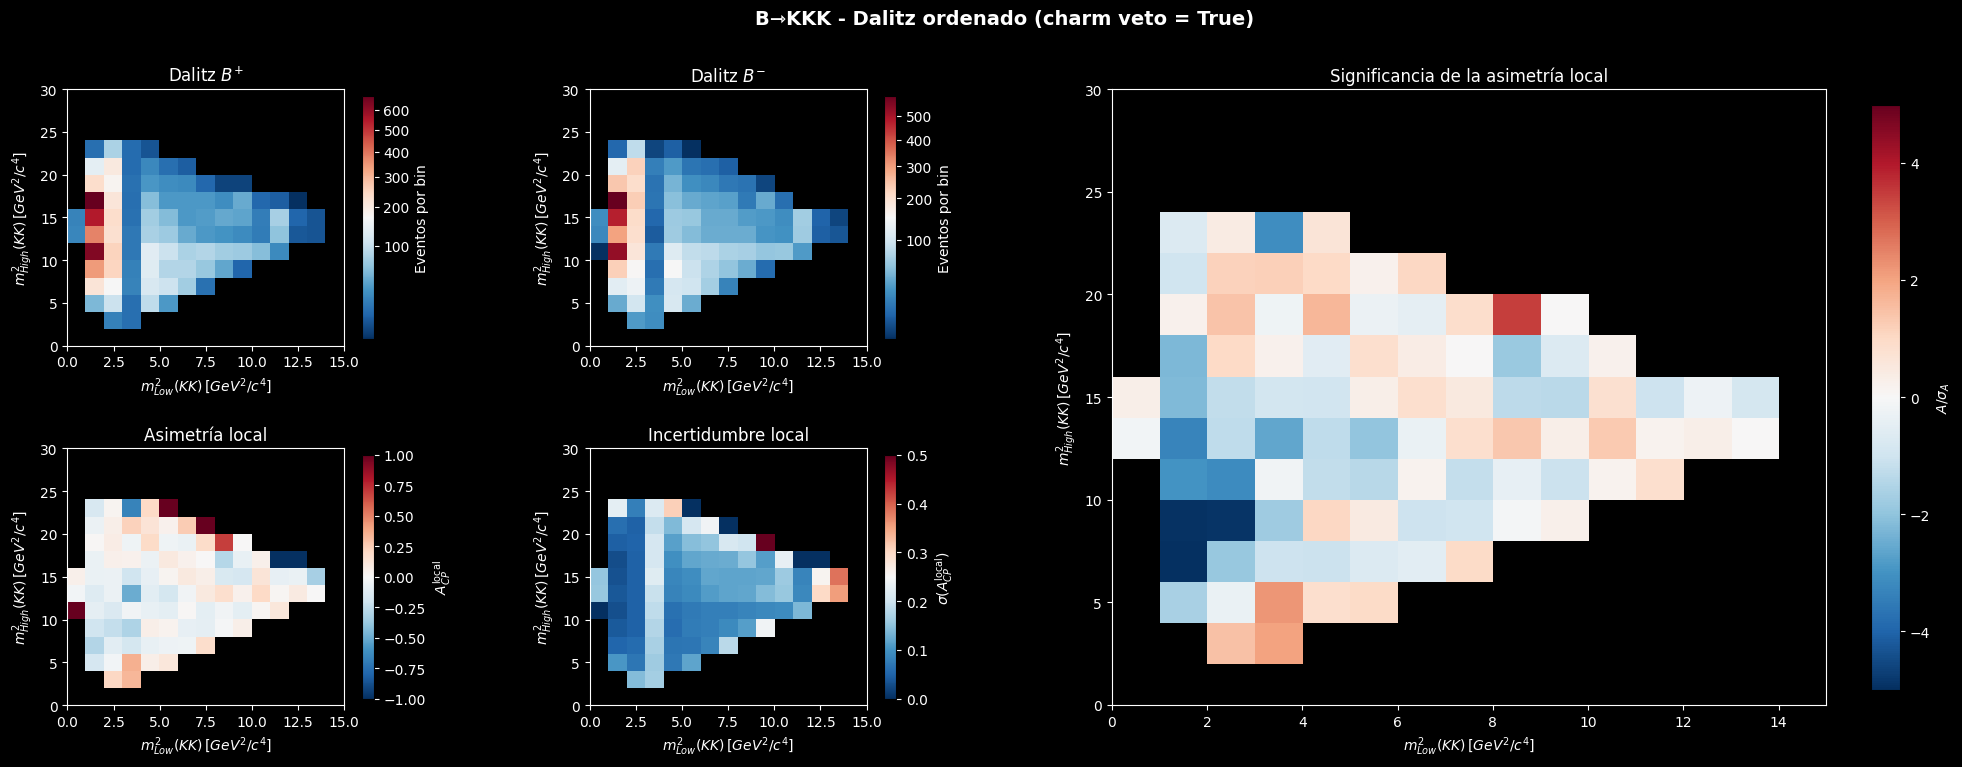

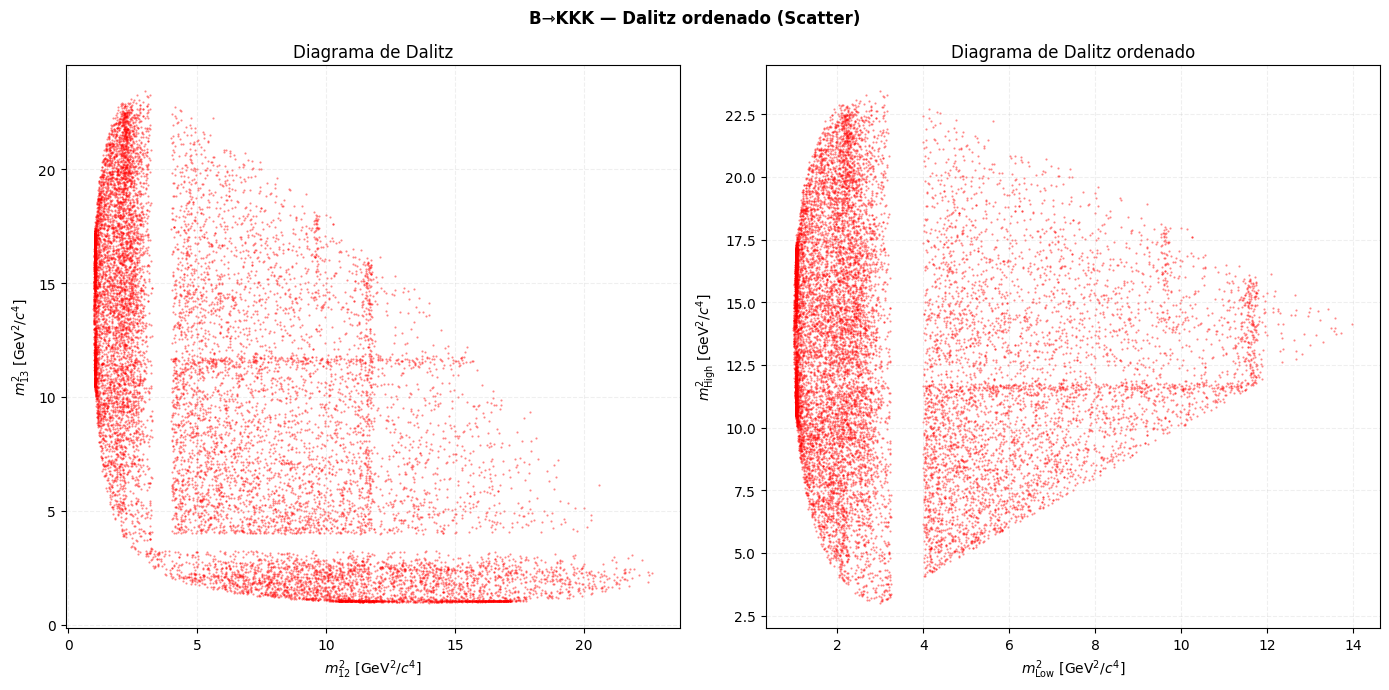


  Análisis completado para B⇾KKK.


In [2]:
PRESELECTION_KKK = (
    '(H1_isMuon==0) & (H2_isMuon==0) & (H3_isMuon==0)'
    ' & (H1_ProbK > 0.5) & (H2_ProbK > 0.5) & (H3_ProbK > 0.5)'
    ' & (H1_ProbPi < 0.5) & (H2_ProbPi < 0.5) & (H3_ProbPi < 0.5)'
)
MASSES_KKK = (mK, mK, mK)

results_KKK = analisis.run_channel_analysis(
    channel_name = "B⇾KKK",
    preselection = PRESELECTION_KKK,
    masses = MASSES_KKK,
    fit_model = 'gauss_exp',
    charm_veto = True,
    use_sideband = False,
    mass_window = (5197, 5364)
)

# Canal $B^{\pm} \to \pi^{+}\pi^{-}\pi^{+}$


  CANAL: B⇾PPP

[1] Cargando datos...
  B2HHH_MagnetUp.root: 414,471 eventos
  B2HHH_MagnetDown.root: 640,342 eventos
  Total tras preselección: 1,054,813 eventos


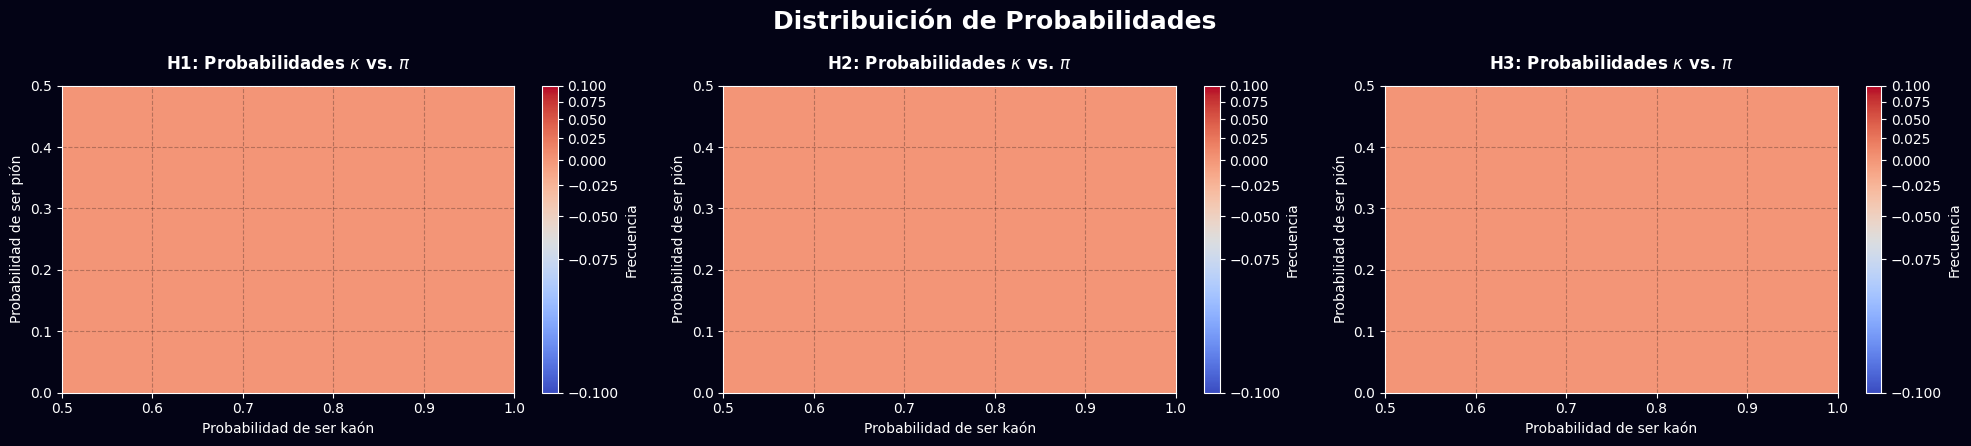


[2] Reconstruyendo masa invariante del B...

[3] Ajuste de la distribución de masa...
  B⁺: 533,262 candidatos en [5100.0,5500.0] [MeV/c²]
N_señal = 8330 ± 385
χ²/ndf  = 137.1 / 73
Media   = 5276.15 [MeV/c²]
  σ     = 27.19 [MeV/c²]
  B⁻: 521,551 candidatos en [5100.0,5500.0] [MeV/c²]
N_señal = 10874 ± 417
χ²/ndf  = 151.5 / 73
Media   = 5278.13 [MeV/c²]
  σ     = 28.87 [MeV/c²]


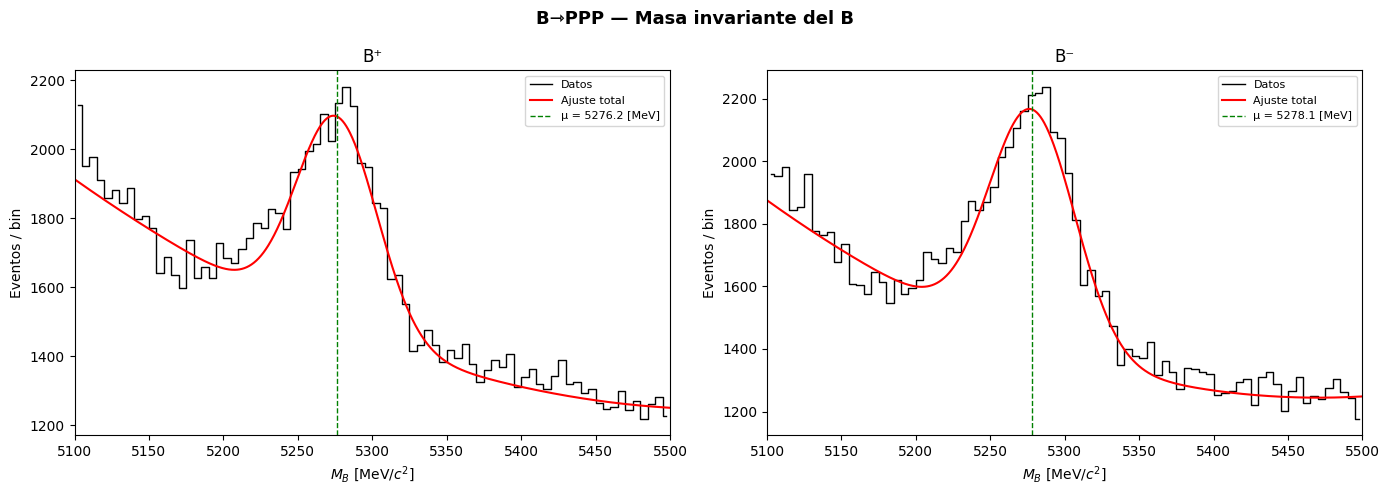


[4] Estimación de fondo por sideband subtraction...
  B⁺:
  Región señal     : 38,346 eventos
  Banda izquierda  : 35,747 eventos
  Banda derecha    : 25,877 eventos
  Fondo estimado   : 31428.2 eventos
  Señal estimada   : 6917.8 eventos
  S/√B             : 39.02
  B⁻:
  Región señal     : 39,369 eventos
  Banda izquierda  : 34,677 eventos
  Banda derecha    : 25,282 eventos
  Fondo estimado   : 30579.1 eventos
  Señal estimada   : 8789.9 eventos
  S/√B             : 50.27

[5] Asimetría CP global (conteo simple)...

=== B⇾PPP — conteo simple ===
  N+ = 533,262   N- = 521,551
  A_CP = -0.0111 ± 0.0010
  Significancia = -11.40 σ

=== B⇾PPP — del ajuste ===
  N+ = 8,330   N- = 10,874
  A_CP = +0.1325 ± 0.0072
  Significancia = +18.52 σ

[6] Diagramas de Dalitz...


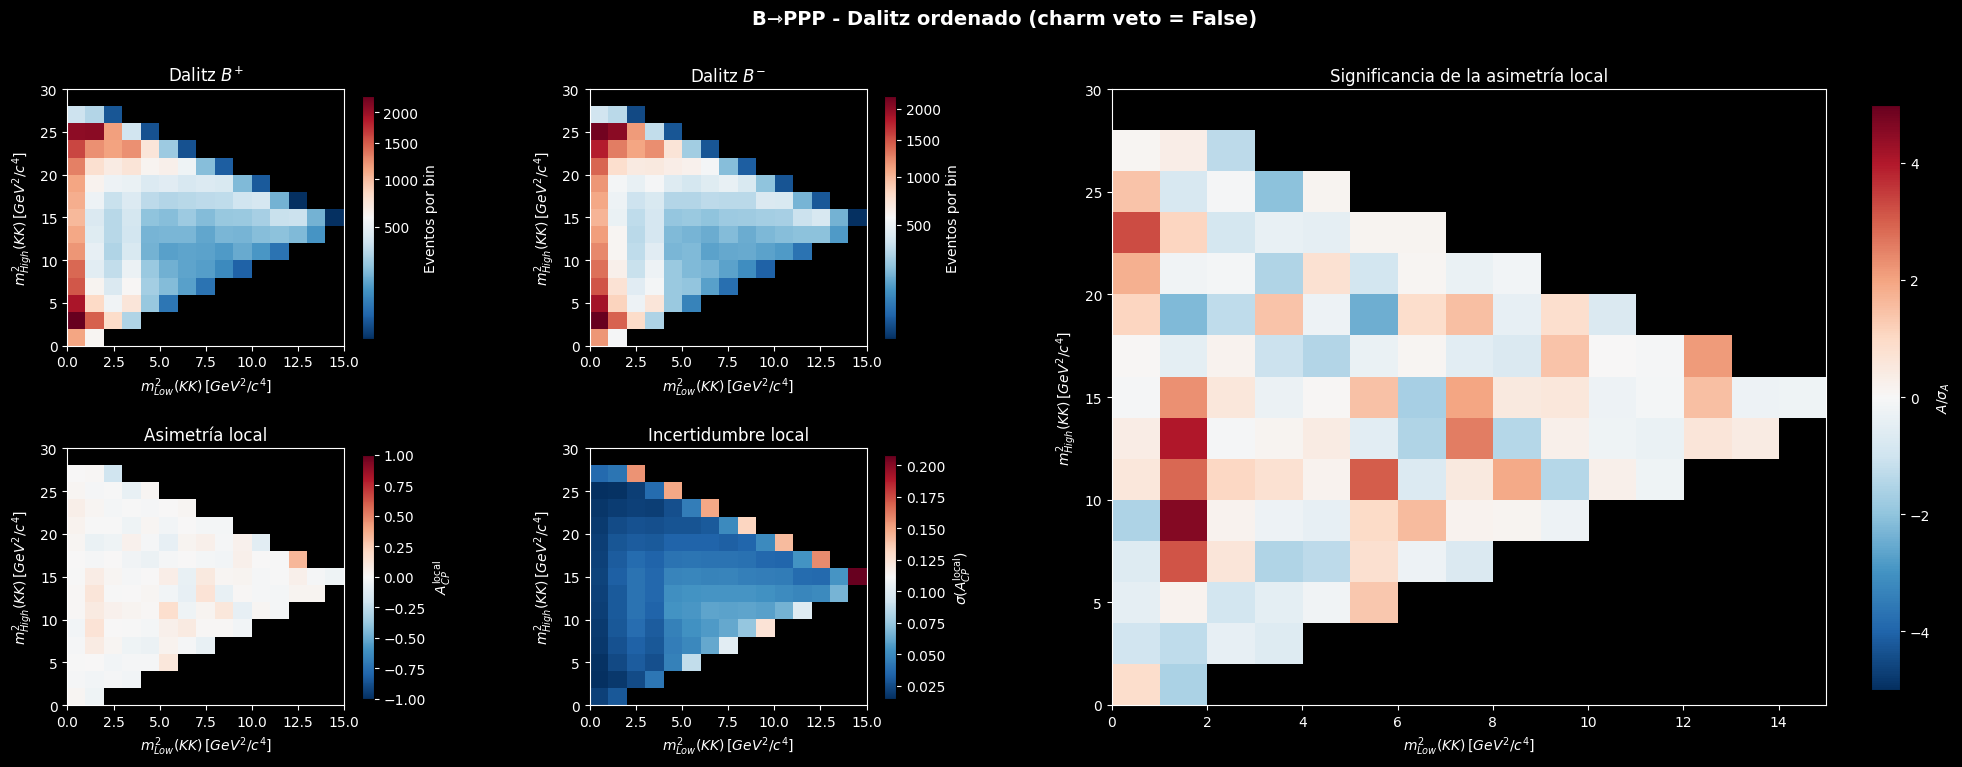

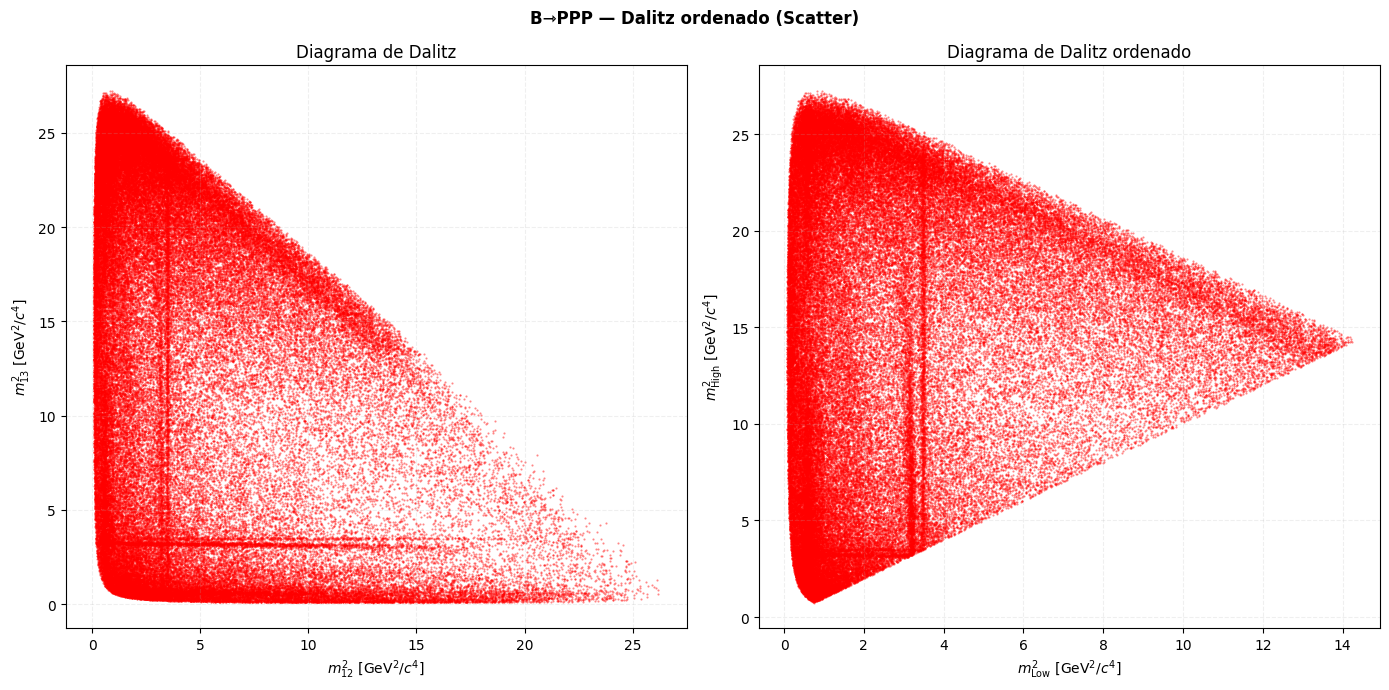


  Análisis completado para B⇾PPP.


In [3]:
PRESELECTION_PPP = (
    '(H1_isMuon==0) & (H2_isMuon==0) & (H3_isMuon==0)'
    ' & (H1_ProbK < 0.5) & (H2_ProbK < 0.5) & (H3_ProbK < 0.5)'
    ' & (H1_ProbPi > 0.5) & (H2_ProbPi > 0.5) & (H3_ProbPi > 0.5)'
)
MASSES_PPP = (mPi, mPi, mPi)

results_PPP = analisis.run_channel_analysis(
    channel_name = "B⇾PPP",
    preselection = PRESELECTION_PPP,
    masses = MASSES_PPP,
    fit_model = 'gauss_cheb',
    charm_veto = False,
    use_sideband = True,
    mass_window = (5197, 5364)
)

# Canal $B^{\pm} \to K^{+}\pi^{-}\pi^{+}$


  CANAL: B⇾KPP

[1] Cargando datos...
  B2HHH_MagnetUp.root: 40,800 eventos
  B2HHH_MagnetDown.root: 63,939 eventos
  Total tras preselección: 104,739 eventos


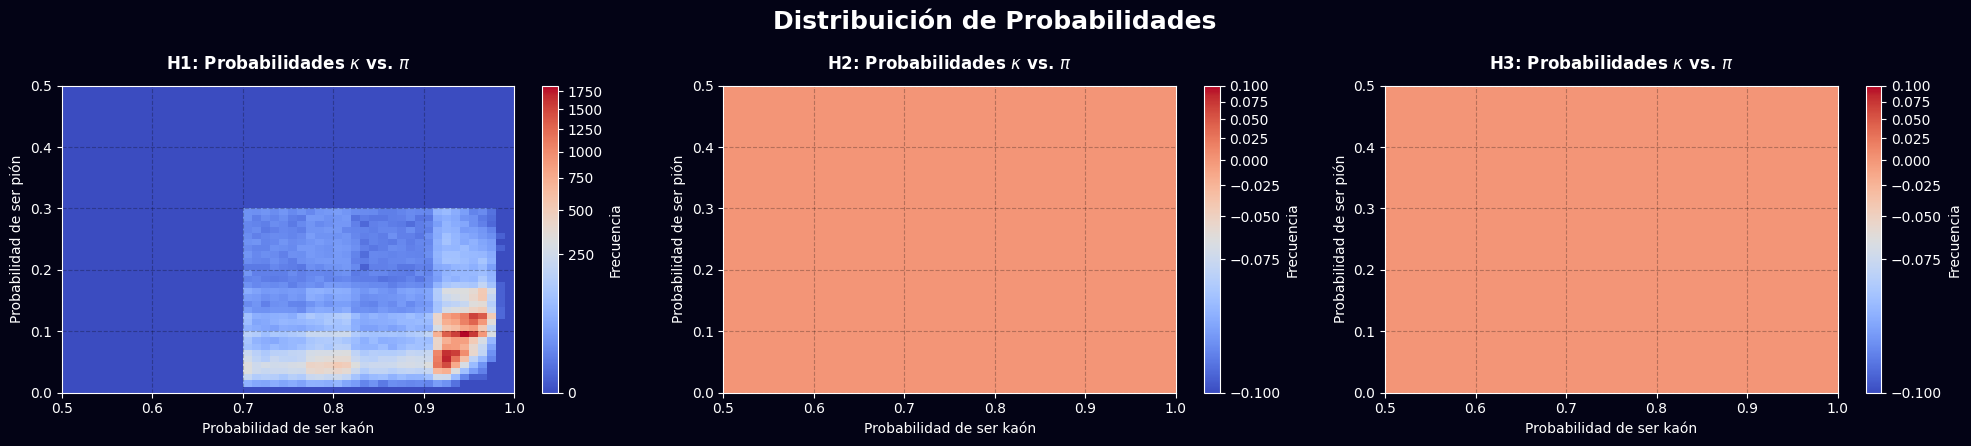


[2] Reconstruyendo masa invariante del B...

[3] Ajuste de la distribución de masa...
  B⁺: 52,297 candidatos en [5100.0,5500.0] [MeV/c²]
N_señal = 691 ± 969
χ²/ndf  = 94.9 / 73
Media   = 5300.44 [MeV/c²]
  σ     = 60.00 [MeV/c²]
  B⁻: 52,442 candidatos en [5100.0,5500.0] [MeV/c²]
N_señal = 161 ± 70
χ²/ndf  = 93.7 / 73
Media   = 5240.00 [MeV/c²]
  σ     = 15.17 [MeV/c²]


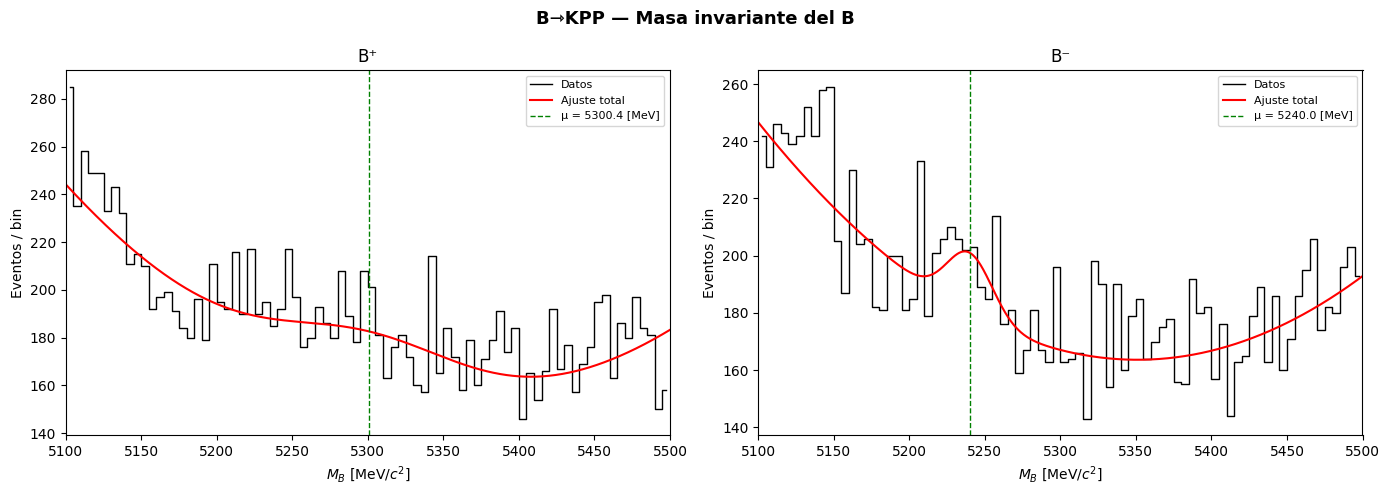


[4] Estimación de fondo por sideband subtraction...
  B⁺:
  Región señal     : 3,833 eventos
  Banda izquierda  : 4,349 eventos
  Banda derecha    : 3,461 eventos
  Fondo estimado   : 3983.1 eventos
  Señal estimada   : -150.1 eventos
  S/√B             : -2.38
  B⁻:
  Región señal     : 3,697 eventos
  Banda izquierda  : 4,430 eventos
  Banda derecha    : 3,568 eventos
  Fondo estimado   : 4079.0 eventos
  Señal estimada   : -382.0 eventos
  S/√B             : -5.98

[5] Asimetría CP global (conteo simple)...

=== B⇾KPP — conteo simple ===
  N+ = 52,297   N- = 52,442
  A_CP = +0.0014 ± 0.0031
  Significancia = +0.45 σ

=== B⇾KPP — del ajuste ===
  N+ = 691   N- = 160
  A_CP = -0.6240 ± 0.0268
  Significancia = -23.29 σ

[6] Diagramas de Dalitz...
  Tras charm veto: 11,119 eventos


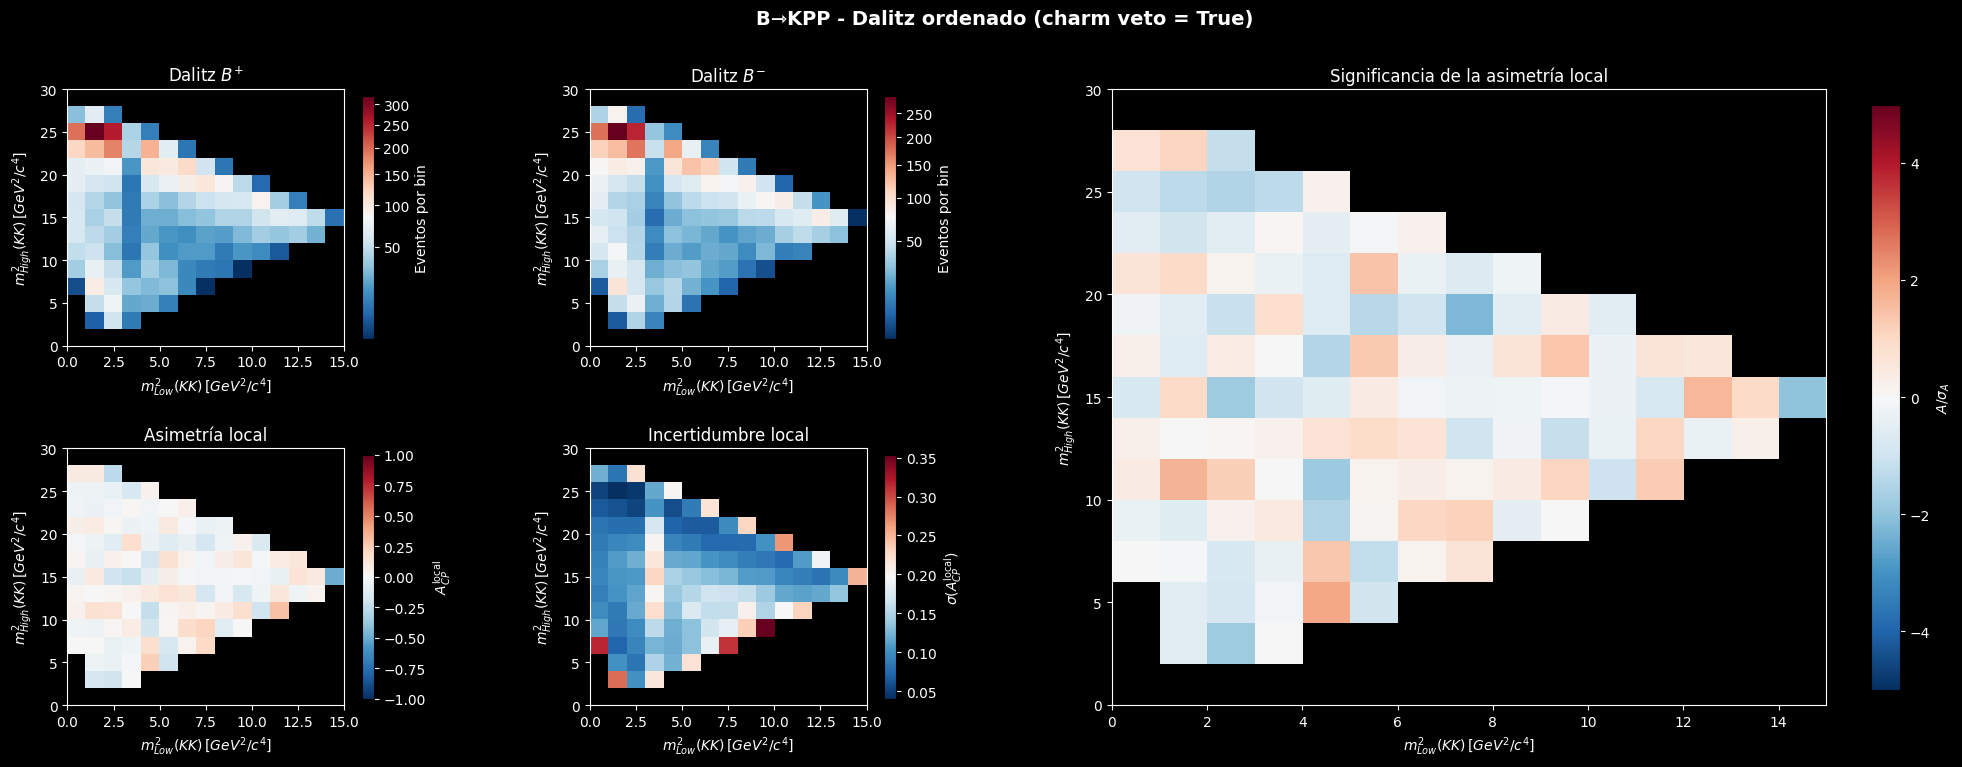

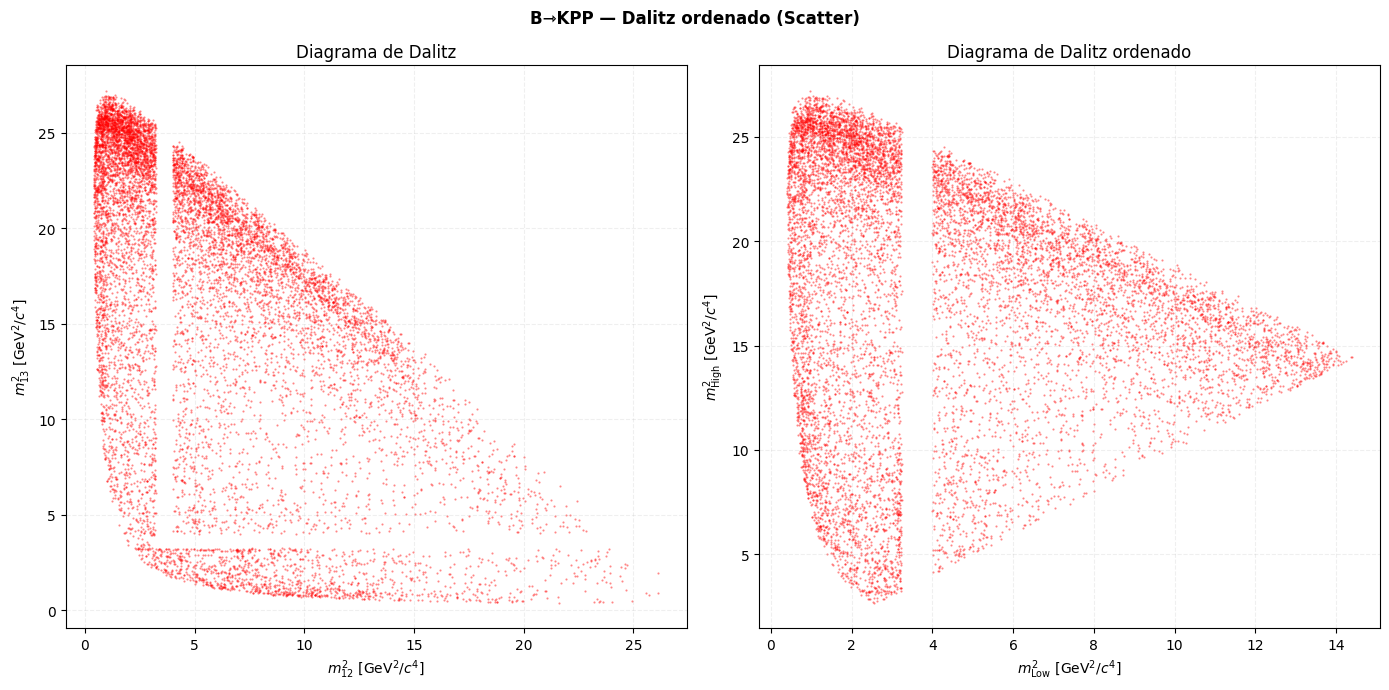


  Análisis completado para B⇾KPP.


In [4]:
PRESELECTION_KPP = (
    '(H1_isMuon==0) & (H2_isMuon==0) & (H3_isMuon==0)'
    ' & (H1_ProbK > 0.7) & (H2_ProbK < 0.5) & (H3_ProbK < 0.5)'
    ' & (H1_ProbPi < 0.3) & (H2_ProbPi > 0.5) & (H3_ProbPi > 0.5)'
)
MASSES_KPP = (mK, mPi, mPi)

results_KPP = analisis.run_channel_analysis(
    channel_name = "B⇾KPP",
    preselection = PRESELECTION_KPP,
    masses = MASSES_KPP,
    fit_model = 'gauss_cheb',
    charm_veto = True,
    use_sideband = True,
    mass_window = (5197, 5364)
)


  CANAL: B⇾PKK

[1] Cargando datos...
  B2HHH_MagnetUp.root: 16,076 eventos
  B2HHH_MagnetDown.root: 24,246 eventos
  Total tras preselección: 40,322 eventos


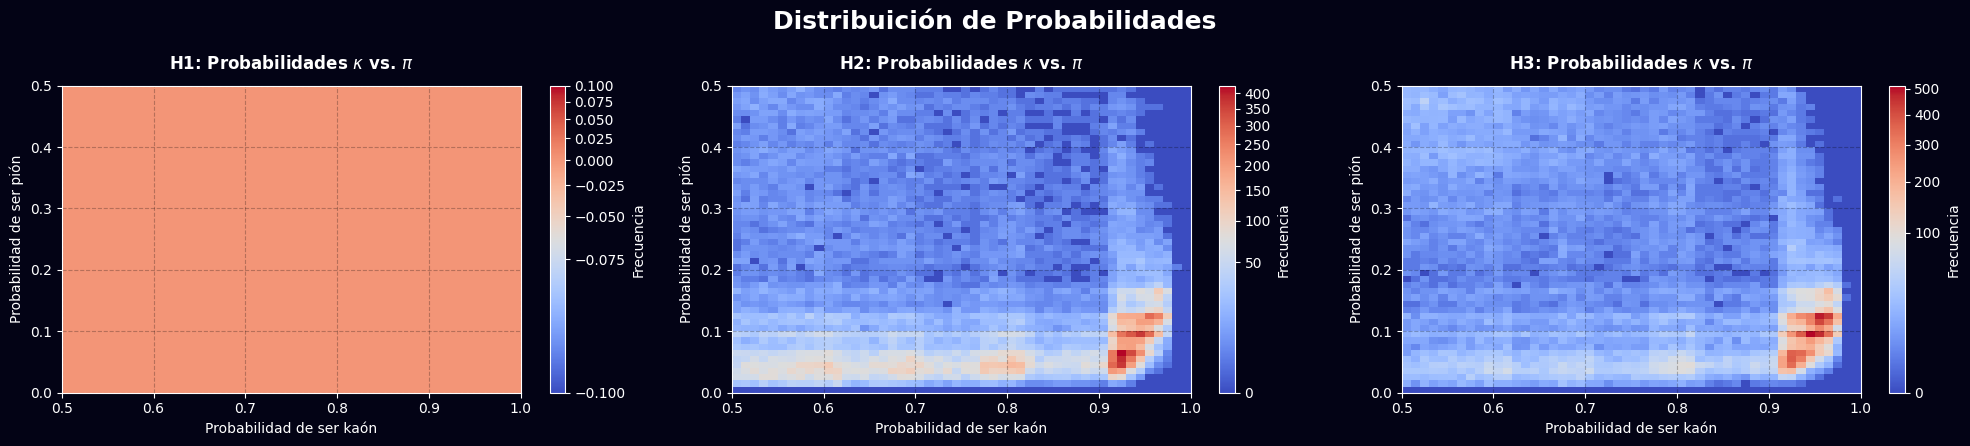


[2] Reconstruyendo masa invariante del B...

[3] Ajuste de la distribución de masa...
  B⁺: 20,942 candidatos en [5100.0,5500.0] [MeV/c²]
N_señal = 1789 ± 113
χ²/ndf  = 163.3 / 73
Media   = 5288.13 [MeV/c²]
  σ     = 30.99 [MeV/c²]
  B⁻: 19,380 candidatos en [5100.0,5500.0] [MeV/c²]
N_señal = 1510 ± 96
χ²/ndf  = 164.6 / 73
Media   = 5289.90 [MeV/c²]
  σ     = 28.67 [MeV/c²]


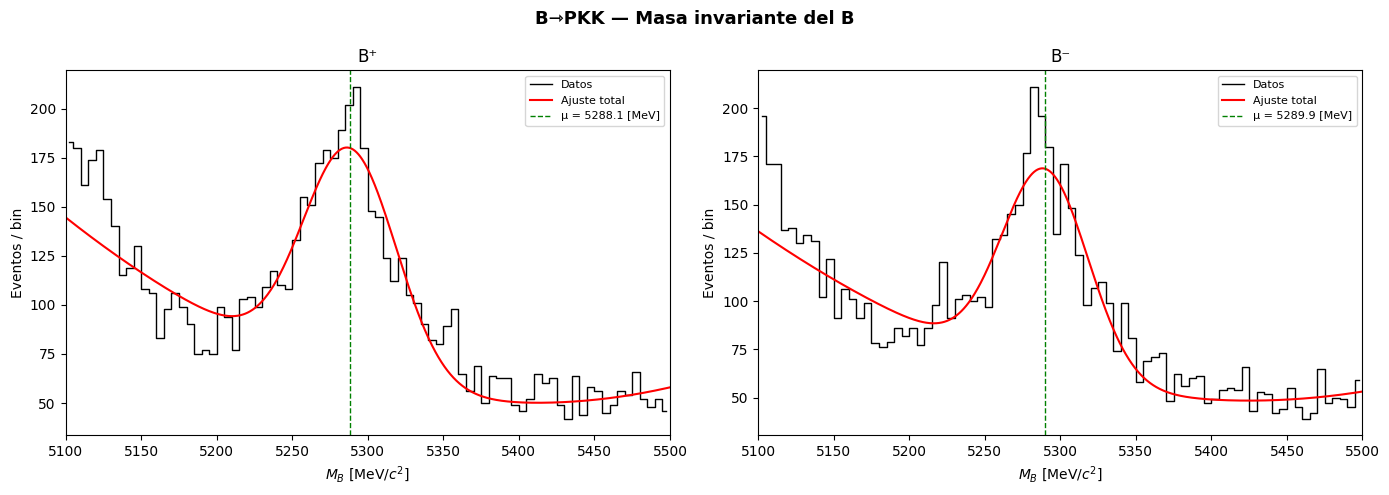


[4] Estimación de fondo por sideband subtraction...
  B⁺:
  Región señal     : 2,990 eventos
  Banda izquierda  : 2,452 eventos
  Banda derecha    : 1,067 eventos
  Fondo estimado   : 1794.7 eventos
  Señal estimada   : 1195.3 eventos
  S/√B             : 28.22
  B⁻:
  Región señal     : 2,757 eventos
  Banda izquierda  : 2,321 eventos
  Banda derecha    : 1,008 eventos
  Fondo estimado   : 1697.8 eventos
  Señal estimada   : 1059.2 eventos
  S/√B             : 25.71

[5] Asimetría CP global (conteo simple)...

=== B⇾PKK — conteo simple ===
  N+ = 20,942   N- = 19,380
  A_CP = -0.0387 ± 0.0050
  Significancia = -7.78 σ

=== B⇾PKK — del ajuste ===
  N+ = 1,789   N- = 1,510
  A_CP = -0.0846 ± 0.0173
  Significancia = -4.87 σ

[6] Diagramas de Dalitz...


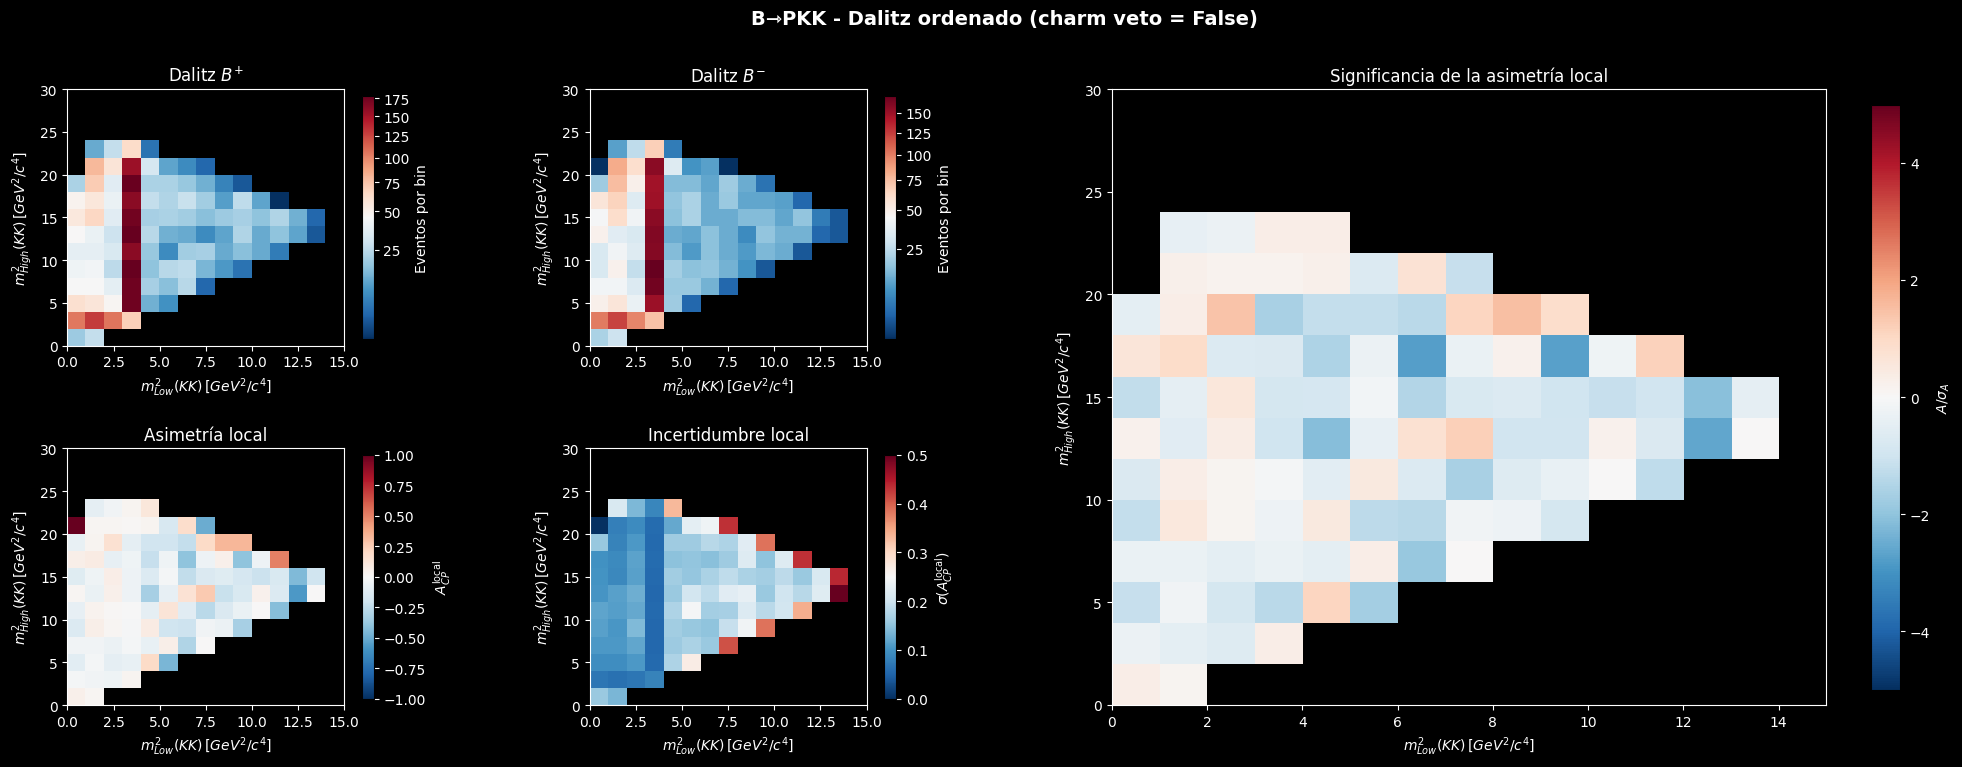

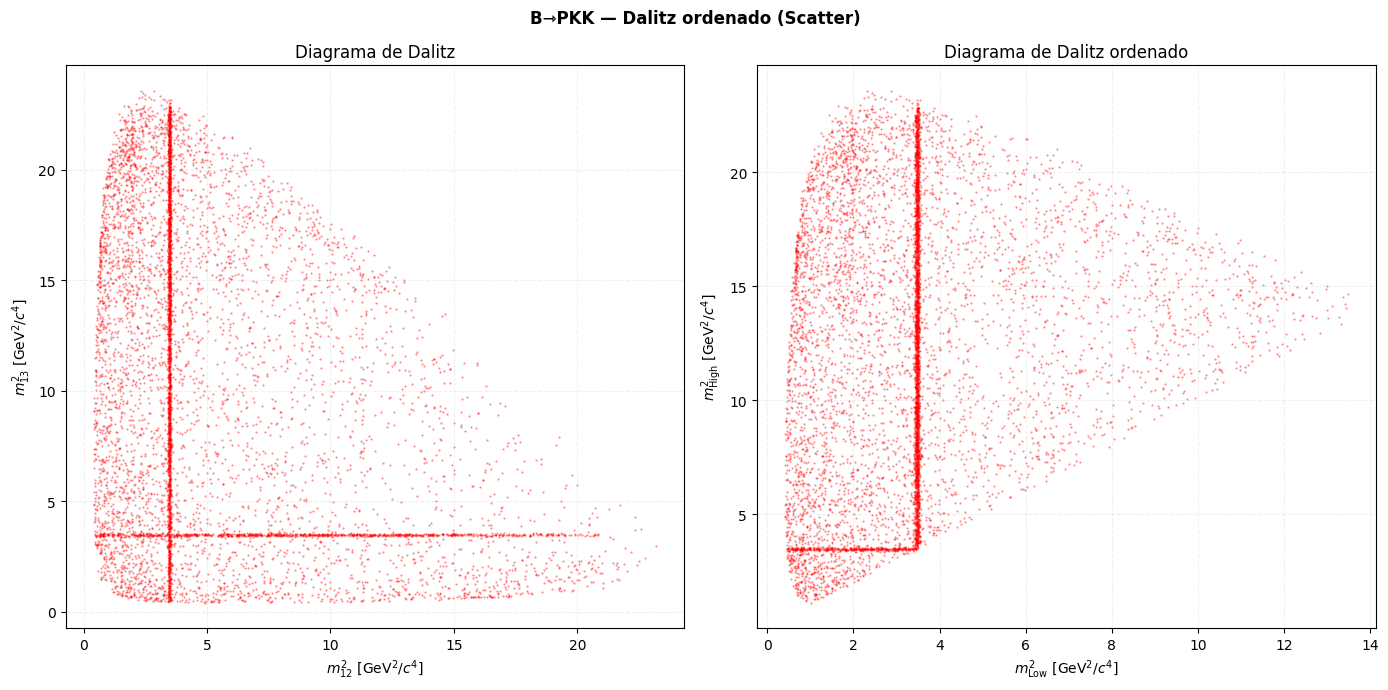


  Análisis completado para B⇾PKK.


In [5]:
PRESELECTION_PKK = (
    '(H1_isMuon==0) & (H2_isMuon==0) & (H3_isMuon==0)'
    ' & (H1_ProbK < 0.5) & (H2_ProbK > 0.5) & (H3_ProbK > 0.5)'
    ' & (H1_ProbPi > 0.5) & (H2_ProbPi < 0.5) & (H3_ProbPi < 0.5)'
)
MASSES_PKK = (mPi, mK, mK)

results_PKK = analisis.run_channel_analysis(
    channel_name = "B⇾PKK",
    preselection = PRESELECTION_PKK,
    masses = MASSES_PKK,
    fit_model = 'gauss_cheb',
    charm_veto = False,
    use_sideband = True,
    mass_window = (5197, 5364)
)